# 02a — Preprocessing (Regression track)

Turns the raw CSV into `dataset/PostProcessed_reg.csv`, the dataset the regression
models train on. Five steps:

1. **Audit** — blank out physically impossible measurements.
2. **Drop leaking columns** — remove everything the target is derived from.
3. **Split** — stratified 80/20, *before* any data-dependent filtering.
4. **Filter** — drop mostly-empty and near-duplicate features, decided on the
   training rows only.
5. **Flag outliers** — ten detectors vote; 9 of 10 agreement flags a row.

Along the way an Optuna study picks the imputation strategy. The implementation
lives in `src/`; this notebook is the driver.

Equivalent to: `python main.py --stage prep-reg`

## 1. Data audit

Ages outside 5–22, a heart rate of 300, a height of 3 inches — these are
data-entry or instrument errors, not real readings. We replace them with NaN
and let the imputer deal with them like any other missing value.

In [1]:
# Make the project's src/ package importable from inside notebooks/.
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import warnings

import numpy as np
import optuna
import pandas as pd

from src.config import (IMPUTER_MASK_FRACTION, IMPUTER_STUDY_N_JOBS,
                        IMPUTER_STUDY_TRIALS, OUTLIER_COMPARE_PERCENTILE,
                        OUTLIER_PERCENTILE, PATHS)
from src.data_loader import (apply_train_only_filters, audit_data,
                             drop_leakage_columns, load_raw_dataset,
                             save_processed_split, split_train_test,
                             validate_processed_file)
from src.imputer_search import create_mask, imputation_objective_regression
from src.outliers import (compute_outlier_scores, detect_consensus_outliers,
                          plot_method_agreement, plot_outlier_embeddings,
                          summarise_outliers)

warnings.filterwarnings("ignore")
os.makedirs(PATHS["results_dir"], exist_ok=True)

dataset = audit_data(load_raw_dataset())
print(f"Dataset shape after audit: {dataset.shape}")

/Users/alessandro/miniforge3/envs/m4_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset shape after audit: (8460, 82)


## 2. Remove target leakage

`sii` is computed directly from the PCIAT questionnaire, so any model that can
see a PCIAT column just reads the answer off its input (QWK ≈ 0.99 — impressive
and completely useless). We drop all 20 PCIAT items, the CGAS clinician score
and the Season columns.

This is a **schema-level** decision: it depends on which columns exist, not on
any row's values, so it is safe to do before the split. The two data-dependent
filters come later, after the split, and are computed on training rows only.

In [2]:
numeric_features = drop_leakage_columns(dataset)
print(f"Shape after leakage-column drop: {numeric_features.shape}")

Shape after leakage-column drop: (8460, 50)


## 3. Train / test split

Every row with a known `sii` label, split 80/20 and stratified so all four
severity levels keep their proportions in both halves — important because
class 3 has only ~90 examples in total.

In [3]:
X_train, X_test, y_train, y_test = split_train_test(numeric_features)

print(f"Labelled pool (non-null sii): {len(X_train) + len(X_test)} rows")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Labelled pool (non-null sii): 8460 rows
X_train: (6768, 47)
X_test:  (1692, 47)


## 4. Train-only feature filters

Two filters, both decided from the training rows and then applied to the test
rows:

- drop any column missing more than 50% of its training values;
- for each pair of columns with Spearman |ρ| > 0.90, drop one — they carry
  the same information twice.

Fitting these on the full dataset would let test rows influence which features
survive, which is a subtle but real form of leakage.

In [4]:
X_train, X_test = apply_train_only_filters(X_train, X_test,
                                           label="Regression")

[Regression] Dropping 0 columns with >50% missing on TRAIN: []
[Regression] Dropping 2 columns with Spearman |rho| > 0.9 on TRAIN: ['BIA-BIA_FFM', 'BIA-BIA_LST']
Final train shape: (6768, 45) | test shape: (1692, 45)
Feature columns aligned: True


## 5. Choosing an imputer

About a third of the cells are empty, so the imputation strategy matters. To
compare candidates we manufacture ground truth: hide 10% of the values that are
*already present*, ask each imputer to reconstruct them, and score its guesses
against what we hid.

The regression study **maximises `0.7 × Spearman − 0.3 × NRMSE`** — mostly
rewarding an imputer that preserves the *ordering* of values, which is what an
ordinal target cares about, with a smaller penalty for absolute error.

See `src/imputer_search.py` for the search space and for the note on the mild
information leak in selecting the imputer once on the whole training pool.

### Which imputer is actually used downstream

The study below re-runs the search. The configuration that won it originally is
recorded in `src/config.py` as `IMPUTER_PARAMS_REG` and is what notebook 03
uses for tuning.

Two things worth knowing:

- The top scorer was `extra_trees` (score 0.37xx), but tuning runs on `mice`
  (ExtraTrees as the per-column estimator): it converged in fewer iterations
  and gave more stable cross-validation residuals. `extra_trees` *is* used at
  final evaluation time — see `IMPUTER_PARAMS_REG_EVAL`.
- The Optuna study is unseeded, so re-running it will not reproduce the
  original best trial exactly.

In [5]:
# Hide 10% of the observed cells, then search for the imputer that
# reconstructs them best.
benchmark_matrix = X_train.values.copy()
mask = create_mask(benchmark_matrix, p=IMPUTER_MASK_FRACTION)

print(f"Benchmark matrix: {benchmark_matrix.shape}")
print(f"Masked entries:   {mask.sum()} "
      f"({100 * mask.sum() / np.prod(benchmark_matrix.shape):.1f}% of cells)\n")

print(f"=== Regression Imputer Study ({IMPUTER_STUDY_TRIALS} trials) ===")
imputer_study = optuna.create_study(direction="maximize")
imputer_study.optimize(
    lambda trial: imputation_objective_regression(
        trial, benchmark_matrix, mask, y_labels=y_train.values),
    n_trials=IMPUTER_STUDY_TRIALS,
    show_progress_bar=True,
    n_jobs=IMPUTER_STUDY_N_JOBS,
)
print(f"Best (reg): {imputer_study.best_params}  "
      f"|  score={imputer_study.best_value:.4f}")

[I 2026-08-03 07:45:37,288] A new study created in memory with name: no-name-814fddd4-a269-49f0-a02f-2cfddf89275c


Benchmark matrix: (6768, 45)
Masked entries:   23884 (7.8% of cells)

=== Regression Imputer Study (100 trials) ===


Best trial: 3. Best value: 0.342175:   1%|          | 1/100 [00:20<33:53, 20.54s/it]

[I 2026-08-03 07:45:57,843] Trial 3 finished with value: 0.34217467052545025 and parameters: {'imputer_choice': 'mice', 'mice_et_estimators': 10, 'mice_et_max_depth': 3, 'mice_max_iter': 8, 'mice_initial_strategy': 'mean'}. Best is trial 3 with value: 0.34217467052545025.


Best trial: 1. Best value: 0.359119:   2%|▏         | 2/100 [00:26<19:36, 12.00s/it]

...

[I 2026-08-03 08:01:02,608] Trial 97 finished with value: 0.3736788316365678 and parameters: {'imputer_choice': 'extra_trees', 'et_estimators': 19, 'et_max_depth': 5, 'et_max_iter': 4, 'et_initial_strategy': 'median'}. Best is trial 50 with value: 0.37445436472657834.


Best trial: 50. Best value: 0.374454:  99%|█████████▉| 99/100 [15:33<00:06,  6.38s/it]

[I 2026-08-03 08:01:10,564] Trial 98 finished with value: 0.33162336461152175 and parameters: {'imputer_choice': 'mice', 'mice_et_estimators': 20, 'mice_et_max_depth': 2, 'mice_max_iter': 5, 'mice_initial_strategy': 'median'}. Best is trial 50 with value: 0.37445436472657834.


Best trial: 50. Best value: 0.374454: 100%|██████████| 100/100 [15:34<00:00,  9.34s/it]

[I 2026-08-03 08:01:11,423] Trial 99 finished with value: 0.33162336461152175 and parameters: {'imputer_choice': 'mice', 'mice_et_estimators': 20, 'mice_et_max_depth': 2, 'mice_max_iter': 6, 'mice_initial_strategy': 'median'}. Best is trial 50 with value: 0.37445436472657834.
Best (reg): {'imputer_choice': 'extra_trees', 'et_estimators': 19, 'et_max_depth': 5, 'et_max_iter': 3, 'et_initial_strategy': 'median'}  |  score=0.3745


## 6. How much do the outlier detectors agree?

Before pooling the ten detectors into a vote, it is worth checking they are not
all saying the same thing. Two methods that agree completely add no independent
evidence; the value of the ensemble comes from them disagreeing in different
places.

Flags here use the 90th percentile (each method's top 10%) — a looser cut than
the consensus vote, so the correlations are easier to read.

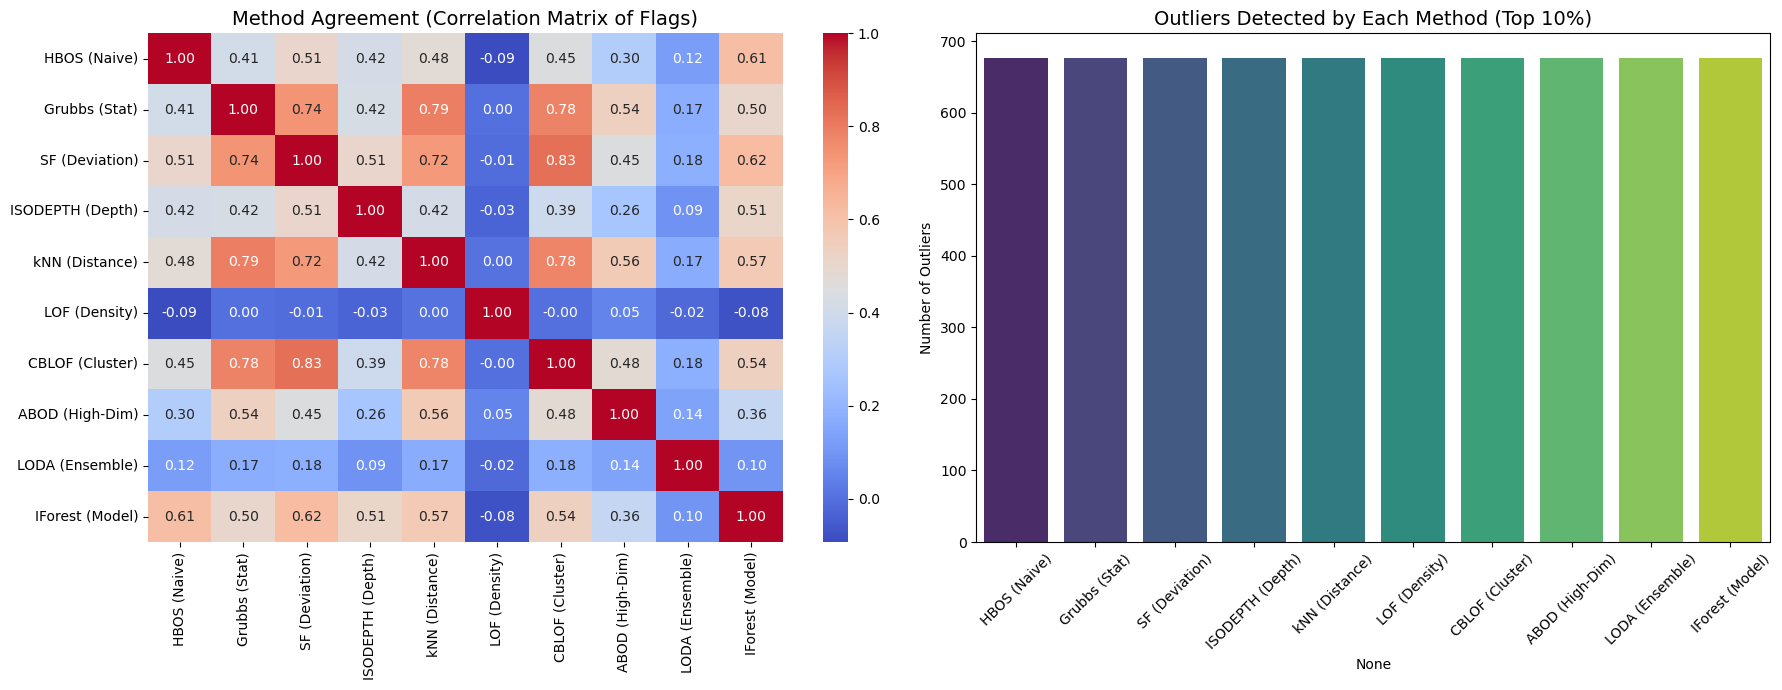

Interpretation: High correlation suggests methods detect similar structures.


In [6]:
# Scoring is stochastic for some detectors (LODA in particular is unseeded),
# so this diagnostic run is independent of the consensus vote below.
plot_method_agreement(compute_outlier_scores(X_train),
                      percentile=OUTLIER_COMPARE_PERCENTILE)

## 7. Consensus outlier detection

Ten detectors, ten different definitions of "unusual":

| Category | Method | What it looks for |
| :-- | :-- | :-- |
| Statistical | HBOS, Grubbs | rare histogram bins; distance from the centre |
| Geometry / depth | Arning SF, ISODEPTH | distance from the centroid / the median |
| Distance | kNN | points far from their neighbours |
| Density | LOF | points in sparser regions than their neighbours |
| Clustering | CBLOF | points that fit no dense cluster |
| High-dimensional | ABOD | points whose angles to others vary little |
| Ensemble | LODA, Isolation Forest | points that are easy to isolate at random |

Each flags its top 1% (99th percentile), and a row is called an outlier only if
**at least 9 of the 10** agree. That deliberately strict rule keeps a single
method's bias from removing real data.

In [7]:
outlier_mask = summarise_outliers(
    detect_consensus_outliers(X_train, OUTLIER_PERCENTILE), y_train.values
)

CONSENSUS OUTLIER DETECTION (10 METHODS)
Total Outliers: 1 / 6768 (0.01%)

Breakdown by class (sii):
 - Class 0: 0 outliers (0.00% of class, 0.00% of total)
 - Class 1: 0 outliers (0.00% of class, 0.00% of total)
 - Class 2: 1 outliers (0.13% of class, 0.01% of total)
 - Class 3: 0 outliers (0.00% of class, 0.00% of total)


## 8. Do the flagged rows actually look different?

A sanity check on the previous step. If the consensus outliers are genuinely
anomalous they should sit apart from the main cloud in at least some 2D
projection. Six embeddings are used because each preserves something different
— global variance (PCA, TSVD), local neighbourhoods (t-SNE, UMAP, PaCMAP) or
graph structure (Spectral) — so an artefact of one is unlikely to show in all.

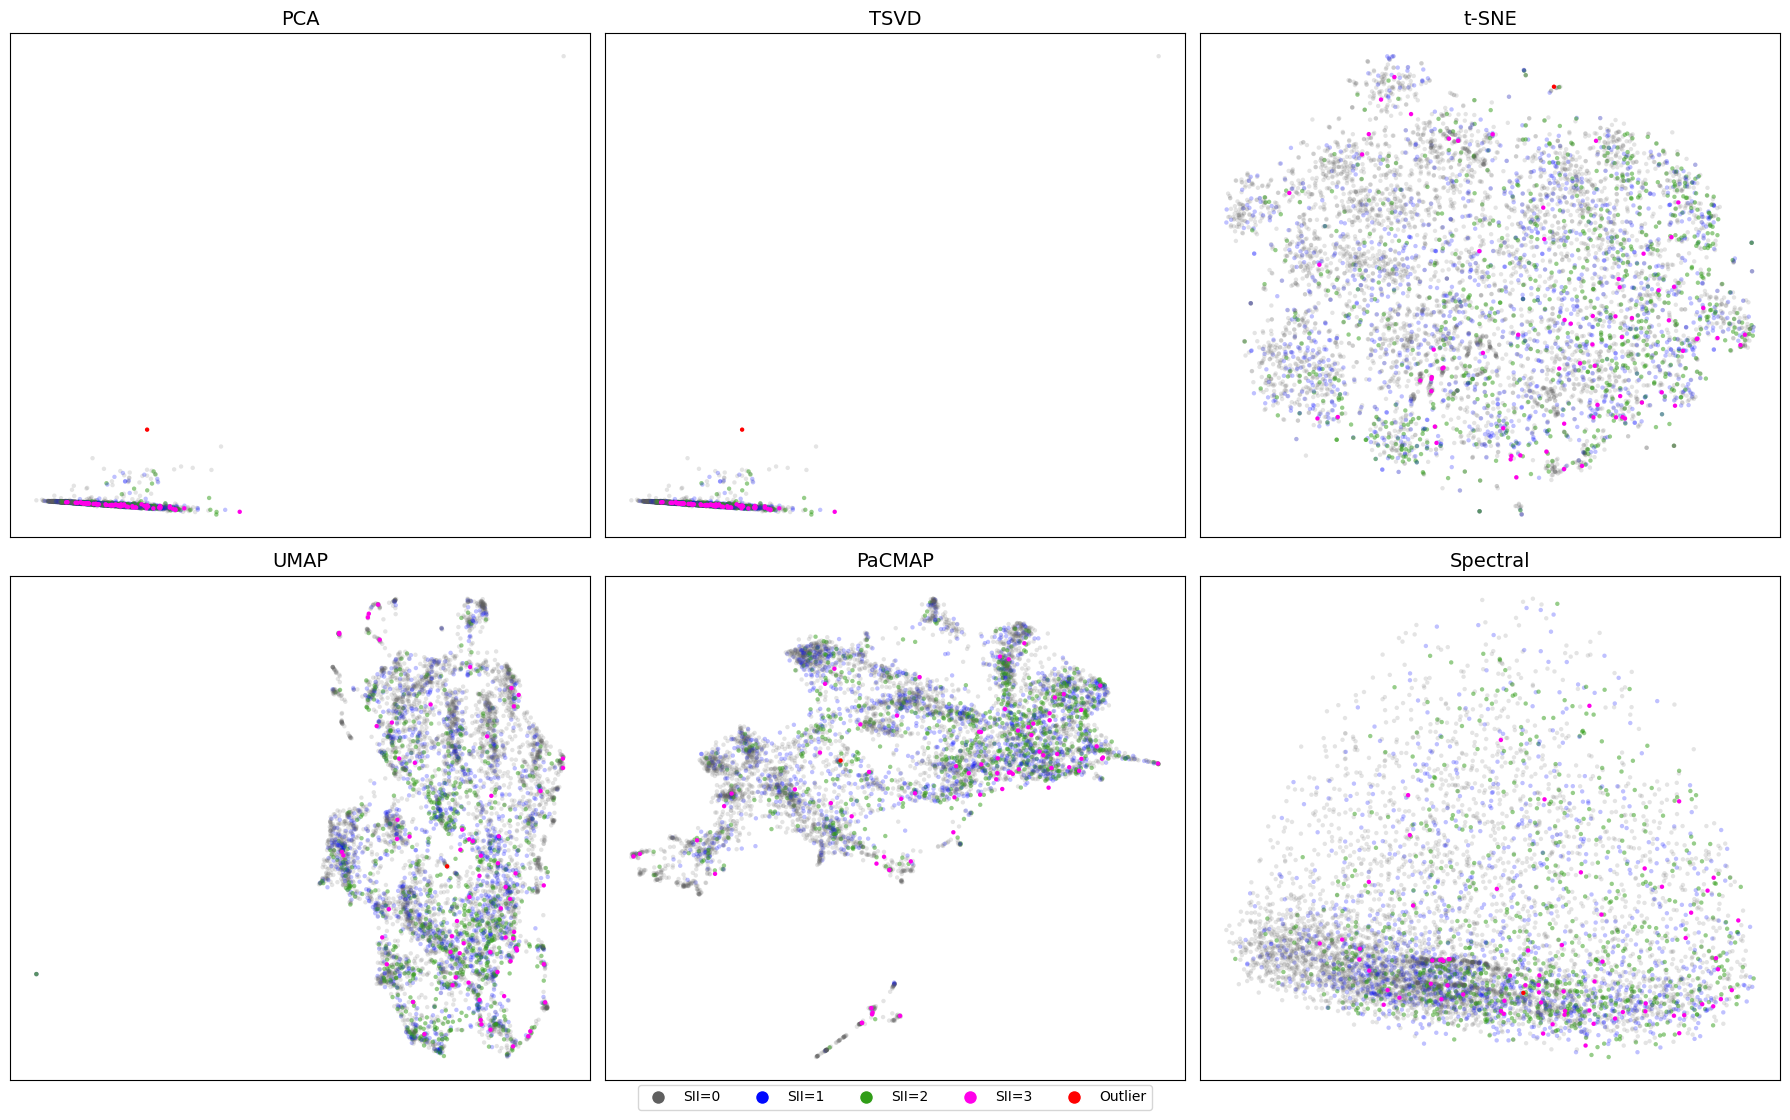

In [8]:
plot_outlier_embeddings(X_train, y_train.values, outlier_mask)

In [9]:
# Write train and test rows to one file, tagged by a Split column, then read
# it back and check it. Outliers are flagged, not dropped — notebook 03 decides
# what to do with them.
save_processed_split(X_train, y_train, X_test, y_test, outlier_mask,
                     PATHS["reg_processed"])

print("\nRegression train sii distribution (including outliers):")
print(y_train.value_counts().sort_index())
print()
validate_processed_file(PATHS["reg_processed"])
print("\nPostProcessed_reg.csv saved. Done.")

Rows written -> Train: 6768, Test: 1692
Outliers flagged in Train: 1 (0.01%)

Regression train sii distribution (including outliers):
sii
0    4666
1    1270
2     762
3      70
Name: count, dtype: int64

Validation - Split values only Train/Test: True -> ['Test', 'Train']
Validation - sii non-null: True
Validation - sii classes in {0,1,2,3}: True -> [0, 1, 2, 3]
Validation - feature columns identical: True

PostProcessed_reg.csv saved. Done.
